In [1]:
# NOTE: unfortunately depends_on_optional machinery in a submodule prevents autoreload from working for that submodule
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from imview import pltlib
from pygeotools.lib import iolib,warplib,geolib
import geopandas as gpd
from shapely.geometry import box
import glob

In [3]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products/WI_Brown_2_2020_processing/wi_brown_highres_ortho

/panfs/ccds02/nobackup/people/sbhusha1/pcd/pcd_first_product_delivery_sep17_25/usgs_pcd_products/WI_Brown_2_2020_processing/wi_brown_highres_ortho


In [4]:
ortho1_fn = 'nuth_subset_104001005B461800_0.35m_ortho.tif'
orth2_fn = 'nuth_subset_104001005ACC6E00_0.35m_ortho.tif'
ds_list = warplib.memwarp_multi_fn([ortho1_fn,orth2_fn])
ortho1,ortho2 = [iolib.ds_getma(ds) for ds in ds_list]


Warping all inputs to the following:
Resolution: 0.35
Extent: [416214.225, 4944214.624999999, 416619.175, 4944359.524999999]
Projection: '+proj=utm +zone=16 +ellps=WGS84 +units=m +no_defs'
Resampling alg: cubic

1 of 2: nuth_subset_104001005B461800_0.35m_ortho.tif
2 of 2: nuth_subset_104001005ACC6E00_0.35m_ortho.tif


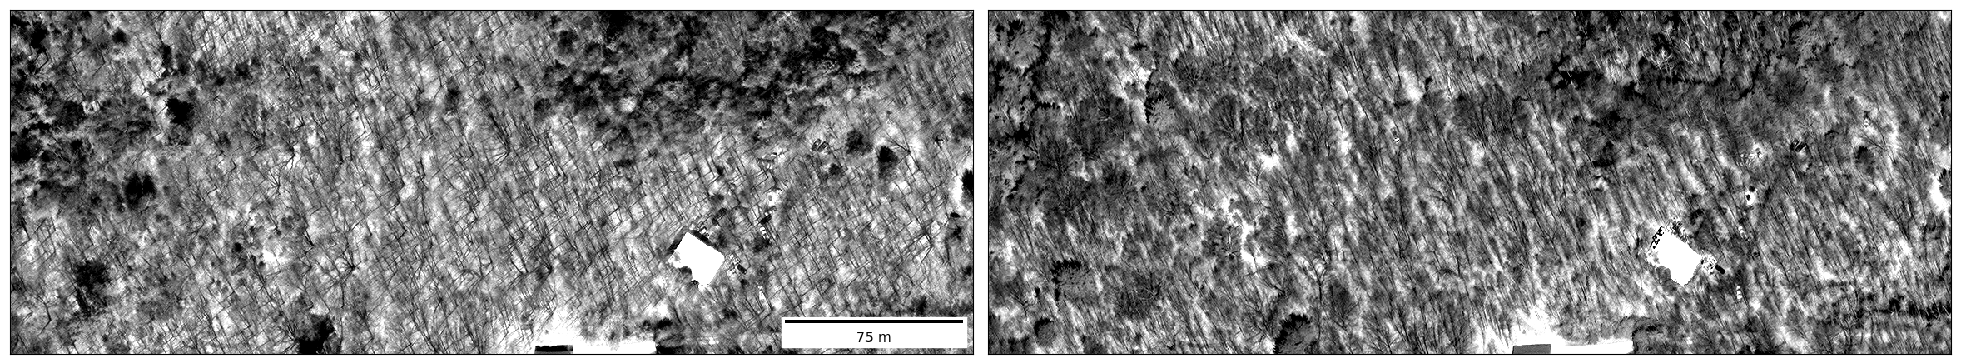

In [22]:
f,ax = plt.subplots(1,2,figsize=(20,20))
pltlib.iv(ortho1,ax=ax[0],cmap='gray',cbar=False)
pltlib.iv(ortho2,ax=ax[1],cmap='gray',cbar=False)
pltlib.add_scalebar(ax=ax[0],res=0.35)
f.savefig('/home/sbhusha1/notebooks/pcd/AGU_ortho_zoomin.png',dpi=300)

In [5]:
%cd /panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs/WI_Brown_2_2020_processing/

/panfs/ccds02/nobackup/people/sbhusha1/pcd/manuscript_prepration/usgs/WI_Brown_2_2020_processing


In [6]:
lidar_dsm_fn = 'WI_Brown_2_2020-DSM_mos.tif'
lidar_dtm_fn = 'WI_Brown_2_2020-DTM_fill_window_size_4_mos.tif'
stereo_dsm_fn = 'stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/20200502_1653_104001005B461800_104001005ACC6E00_1.0m-DEM_trans_dx+2.79m_dy-1.04m_dz-0.10m.tif'
ds_list = warplib.memwarp_multi_fn([lidar_dsm_fn,lidar_dtm_fn,stereo_dsm_fn],extent=[416214.225, 4944214.624999999, 416619.175, 4944359.524999999])
lidar_dsm,lidar_dtm,stereo_dsm = [iolib.ds_getma(ds) for ds in ds_list]


Warping all inputs to the following:
Resolution: 1.0
Extent: [416214.225, 4944214.624999999, 416619.175, 4944359.524999999]
Projection: '+proj=utm +zone=16 +ellps=WGS84 +units=m +no_defs'
Resampling alg: cubic

1 of 3: WI_Brown_2_2020-DSM_mos.tif
nl: 145 ns: 405 res: 1.000
0...10...20...30...40...50...60...70...80...90...2 of 3: WI_Brown_2_2020-DTM_fill_window_size_4_mos.tif
nl: 145 ns: 405 res: 1.000
100 - done.
0...10...20...30...40...50...60...70...80...90...3 of 3: stereo_WV03WV03_20200502_104001005B461800_104001005ACC6E00/20200502_1653_104001005B461800_104001005ACC6E00_1.0m-DEM_trans_dx+2.79m_dy-1.04m_dz-0.10m.tif
nl: 145 ns: 405 res: 1.000
100 - done.
0...10...20...30...40...50...60...70...80...90...

In [7]:
ds_extent = geolib.ds_extent(ds_list[0])
fig_extent = [ds_extent[0],ds_extent[2],ds_extent[1],ds_extent[3]]

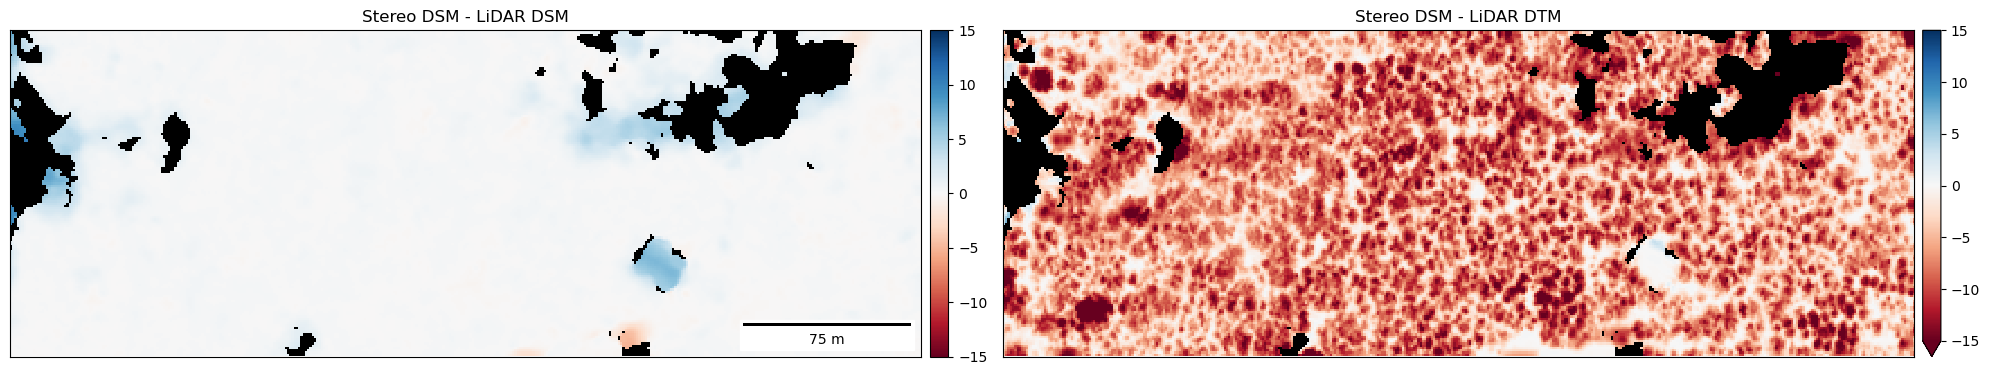

In [10]:
f,ax = plt.subplots(1,2,figsize=(20,20))
pltlib.iv(stereo_dsm - lidar_dtm,ax=ax[0],cmap='RdBu',clim=(-15,15),extent=fig_extent,title='Stereo DSM - LiDAR DSM')
pltlib.iv(stereo_dsm - lidar_dsm,ax=ax[1],cmap='RdBu',clim=(-15,15),extent=fig_extent,title='Stereo DSM - LiDAR DTM')
pltlib.add_scalebar(ax=ax[0],res=1.0)
f.savefig('/home/sbhusha1/notebooks/pcd/DSM_DTM_comparison_zoomin.png',dpi=300)

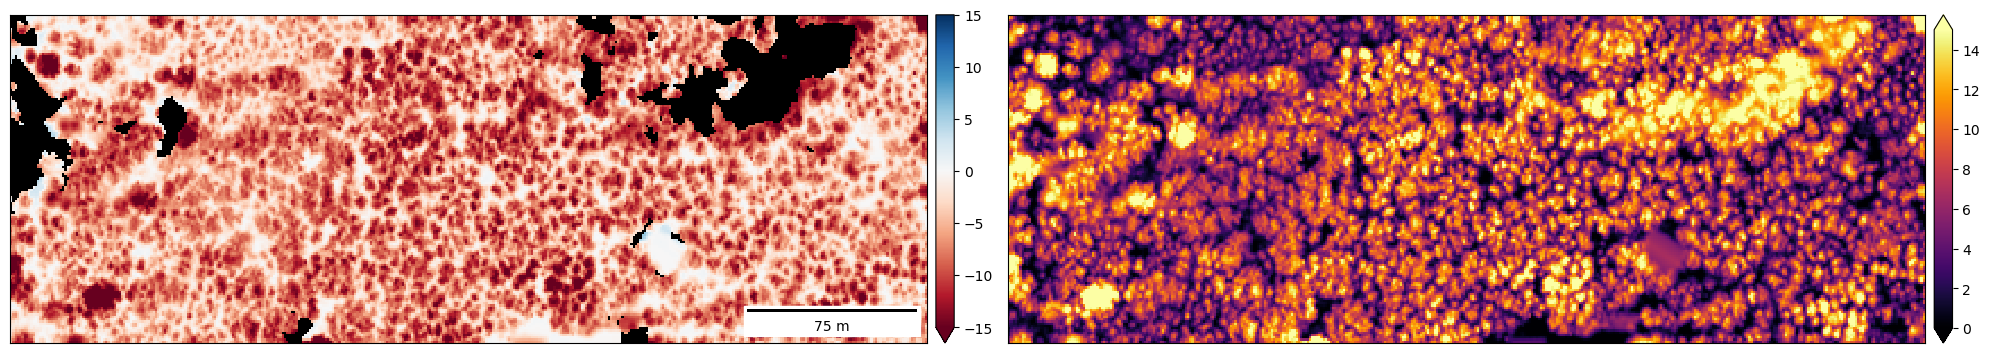

In [38]:
f,ax = plt.subplots(1,2,figsize=(20,20))
pltlib.iv(stereo_dsm - lidar_dsm,ax=ax[0],cmap='RdBu',clim=(-15,15),extent=fig_extent)
pltlib.iv(lidar_dsm - lidar_dtm,ax=ax[1],cmap='inferno',clim=(0,15),extent=fig_extent)
pltlib.add_scalebar(ax=ax[0],res=1.0)
f.savefig('/home/sbhusha1/notebooks/pcd/CHM_zoomin.png',dpi=300)

In [30]:
profile = gpd.read_file('/home/sbhusha1/notebooks/pcd/Profile-adapt.gpkg')

/home/sbhusha1/.conda/envs/bhushan_gdal3/lib/python3.13/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


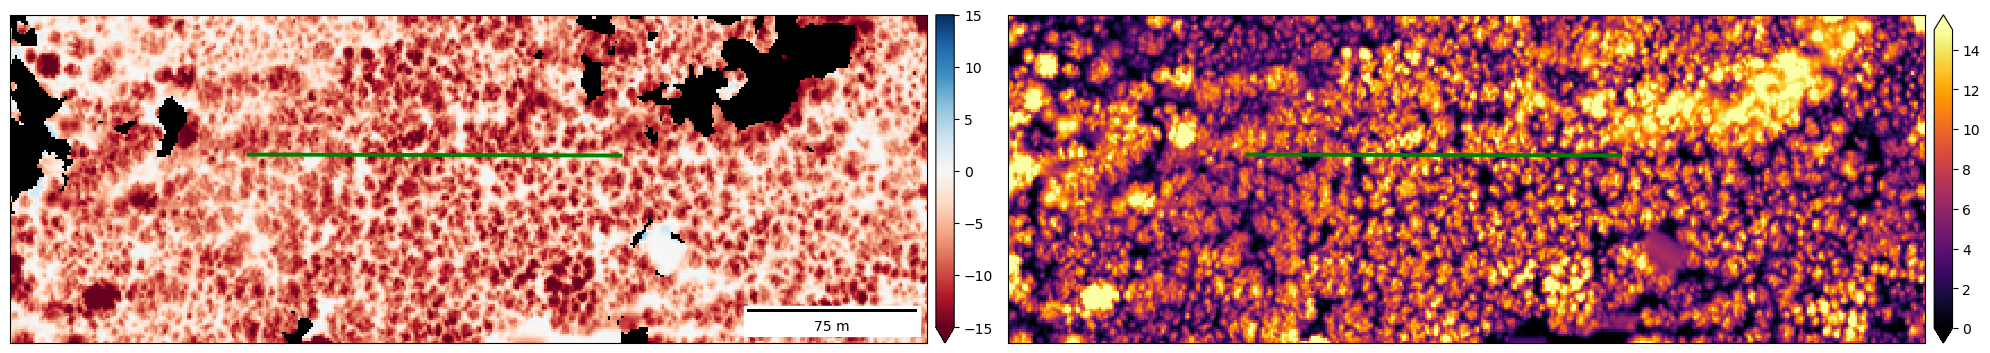

In [39]:
f,ax = plt.subplots(1,2,figsize=(20,20))
pltlib.iv(stereo_dsm - lidar_dsm,ax=ax[0],cmap='RdBu',clim=(-15,15),extent=fig_extent)
pltlib.iv(lidar_dsm - lidar_dtm,ax=ax[1],cmap='inferno',clim=(0,15),extent=fig_extent)
pltlib.add_scalebar(ax=ax[0],res=1.0)
profile.plot(ax=ax[0],color='green',linewidth=2.8)
ax[0].set_aspect('equal')
profile.plot(ax=ax[1],color='green',linewidth=2.8)
ax[1].set_aspect('equal')
f.savefig('/home/sbhusha1/notebooks/pcd/CHM_zoomin_profile.png',dpi=300)